In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import os


feature_path = os.path.abspath(r"C:\Users\alexg\OneDrive\Documents\NBA-Prop-Predictor")
# feature_path = os.path.abspath('/Users/alexg/Documents/Documents/Prize-Picks-Prop-Predictor')
if feature_path not in sys.path:
    sys.path.append(feature_path)

from FEATURES.features import *
from PROPS_EV.calculateEVS import *
from BACKTEST.backtest import *
from MODELS.Models import *

In [2]:
model = joblib.load('../MODELS/Models/xgbModel.pkl')
features = joblib.load('../MODELS/Models/top_features.pkl')

In [3]:
pd.set_option('display.max_columns', None)

s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')

df = pd.concat([s25, s24]).sort_values(by='GAME_DATE')

In [18]:
backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')
backtestData = backtestData[(backtestData['CATEGORY'] == 'player_points') & (backtestData['BOOKMAKER'] == 'prizepicks')]
backtestData

C:\Users\alexg\AppData\Local\Temp\ipykernel_8788\234261984.py:1: DtypeWarning: Columns (11,12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')


,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,NAME,CATEGORY,BOOKMAKER,SIDE,LINE,ODDS,HOME_TEAM,AWAY_TEAM,game_id,commence_time,GAME_DATE,period_id,fair_line,fair_odds,OVER/ODDS
0,0,0,0,Miles McBride,player_points,prizepicks,under,8.5,-137,Boston Celtics,New York Knicks,92cf7db605a734b10e69eabf56e1eac9,2024-10-22T23:40:00Z,2024-10-22,NaN,NaN,NaN,under
3,3,3,3,Jayson Tatum,player_points,prizepicks,over,26.5,-137,Boston Celtics,New York Knicks,92cf7db605a734b10e69eabf56e1eac9,2024-10-22T23:40:00Z,2024-10-22,NaN,NaN,NaN,over
4,4,4,4,Jayson Tatum,player_points,prizepicks,under,26.5,-137,Boston Celtics,New York Knicks,92cf7db605a734b10e69eabf56e1eac9,2024-10-22T23:40:00Z,2024-10-22,NaN,NaN,NaN,under
5,5,5,5,Jalen Brunson,player_points,prizepicks,over,27.5,-137,Boston Celtics,New York Knicks,92cf7db605a734b10e69eabf56e1eac9,2024-10-22T23:40:00Z,2024-10-22,NaN,NaN,NaN,over
6,6,6,6,Jalen Brunson,player_points,prizepicks,under,27.5,-137,Boston Celtics,New York Knicks,92cf7db605a734b10e69eabf56e1eac9,2024-10-22T23:40:00Z,2024-10-22,NaN,NaN,NaN,under
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198078,198078,198078,119117,Blake Wesley,player_points,prizepicks,under,9.5,-137,San Antonio Spurs,Toronto Raptors,NaN,NaN,2025-04-13,game,9.5,-108.0,under
198083,198083,198083,119122,Malaki Branham,player_points,prizepicks,over,11.5,-137,San Antonio Spurs,Toronto Raptors,NaN,NaN,2025-04-13,game,12.5,100.0,over
198089,198089,198089,119128,Malaki Branham,player_points,prizepicks,under,11.5,-137,San Antonio Spurs,Toronto Raptors,NaN,NaN,2025-04-13,game,12.5,100.0,under
198095,198095,198095,119134,Garrett Temple,player_points,prizepicks,under,9.5,-137,San Antonio Spurs,Toronto Raptors,NaN,NaN,2025-04-13,game,9.5,-115.0,under


In [19]:
results = backtestPrizePicksPairs(df, backtestData, '2025-03-28', model, features, edge_threshold=4.5, top_n=10, simulations=10000)
results

Processing pairs...


,player1,player2,side1,side2,model_side1,model_side2,line1,line2,pred1,pred2,actual1,actual2,edge1,edge2,leg1_won,leg2_won,pair_recommendation,pair_won,ev_percent,probability,date
0,Brice Sensabaugh,Patrick Williams,over,under,OVER,OVER,9.5,7.5,16.61,14.26,17,11,7.11,6.76,1,1,1,1,1.853,0.9508,2025-03-28
1,Brice Sensabaugh,Chet Holmgren,over,over,OVER,UNDER,9.5,16.5,16.61,11.09,17,4,7.11,-5.41,1,1,1,1,1.765,0.9216,2025-03-28
2,Brice Sensabaugh,Kris Dunn,over,over,OVER,OVER,9.5,5.5,16.61,9.49,17,9,7.11,3.99,1,1,0,1,1.749,0.9162,2025-03-28
3,Collin Sexton,Patrick Williams,over,under,OVER,OVER,16.5,7.5,23.22,14.26,21,11,6.72,6.76,1,1,1,1,1.682,0.8940,2025-03-28
4,Chet Holmgren,Patrick Williams,over,under,UNDER,OVER,16.5,7.5,11.09,14.26,4,11,-5.41,6.76,1,1,1,1,1.657,0.8858,2025-03-28
5,Kris Dunn,Patrick Williams,over,under,OVER,OVER,5.5,7.5,9.49,14.26,9,11,3.99,6.76,1,1,0,1,1.642,0.8807,2025-03-28
6,Brice Sensabaugh,Nikola Vučević,over,under,OVER,OVER,9.5,15.5,16.61,22.44,17,14,7.11,6.94,1,0,1,0,1.610,0.8701,2025-03-28
7,Chet Holmgren,Collin Sexton,over,over,UNDER,OVER,16.5,16.5,11.09,23.22,4,21,-5.41,6.72,1,1,1,1,1.599,0.8665,2025-03-28
8,Brice Sensabaugh,Steven Adams,over,over,OVER,OVER,9.5,5.5,16.61,7.78,17,7,7.11,2.28,1,1,0,1,1.589,0.8631,2025-03-28
9,Collin Sexton,Kris Dunn,over,over,OVER,OVER,16.5,5.5,23.22,9.49,21,9,6.72,3.99,1,1,0,1,1.584,0.8614,2025-03-28


In [20]:
if not results.empty:
    # Overall metrics
    total_bets = len(results)
    total_wins = results['pair_won'].sum()
    win_rate = results['pair_won'].mean()
    
    # Metrics for recommended bets only
    recommended = results[results['pair_recommendation'] == 1]
    if not recommended.empty:
        rec_total = len(recommended)
        rec_wins = recommended['pair_won'].sum()
        rec_win_rate = recommended['pair_won'].mean()
        
        print(f"\n--- All Bets ---")
        print(f"Total: {total_bets}, Wins: {total_wins}, Win Rate: {win_rate:.2%}")
        print(f"\n--- Recommended Bets (Edge > 4.5) ---")
        print(f"Total: {rec_total}, Wins: {rec_wins}, Win Rate: {rec_win_rate:.2%}")


--- All Bets ---
Total: 10, Wins: 9, Win Rate: 90.00%

--- Recommended Bets (Edge > 4.5) ---
Total: 6, Wins: 5, Win Rate: 83.33%


In [28]:
uniqueDates = sorted(s25['GAME_DATE'].unique())
all_results = []

for i, date in enumerate(uniqueDates, 1):
    print(f"Processing {date}... {i}/{len(uniqueDates)}")
    
    try:
        date_results = backtestPrizePicksPairs(df, backtestData, date, model, features, edge_threshold=5.5, top_n=10, simulations=10000)
        
        if not date_results.empty:
            all_results.append(date_results)
            print(f"  ✓ Processed {len(date_results)} bets")
        else:
            print(f"  No results for {date}")
        
    except Exception as e:
        print(f"  ✗ Error: {e}")
        continue

# Combine all results
if all_results:
    final_results = pd.concat(all_results, ignore_index=True)
    print(f"\n✓ Complete! Total bets analyzed: {len(final_results)}")



Processing 2024-10-23... 1/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-24... 2/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-25... 3/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-26... 4/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-27... 5/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-28... 6/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-29... 7/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-30... 8/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-31... 9/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-11-01... 10/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-11-02... 11/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-11-03... 12/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-11-04... 13/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-11-06... 14/162
Processing pair

           COMPREHENSIVE BETTING ANALYSIS

 ALL BETS ANALYSIS:
   Total Bets: 1,410
   Wins: 676
   Hit Rate: 47.94%
   Total Profit: $3,090.00
   Total Staked: $7,050.00
   ROI: 43.83%
   Volatility: $43.23
   Max Drawdown: $-290.00
   Sharpe Ratio: 6.019

 RECOMMENDED BETS ANALYSIS (Edge > 5.5):
   Total Bets: 296
   Wins: 162
   Hit Rate: 54.73%
   Total Profit: $950.00
   Total Staked: $1,480.00
   ROI: 64.19%
   Volatility: $24.17
   Max Drawdown: $-125.00
   Sharpe Ratio: 4.215


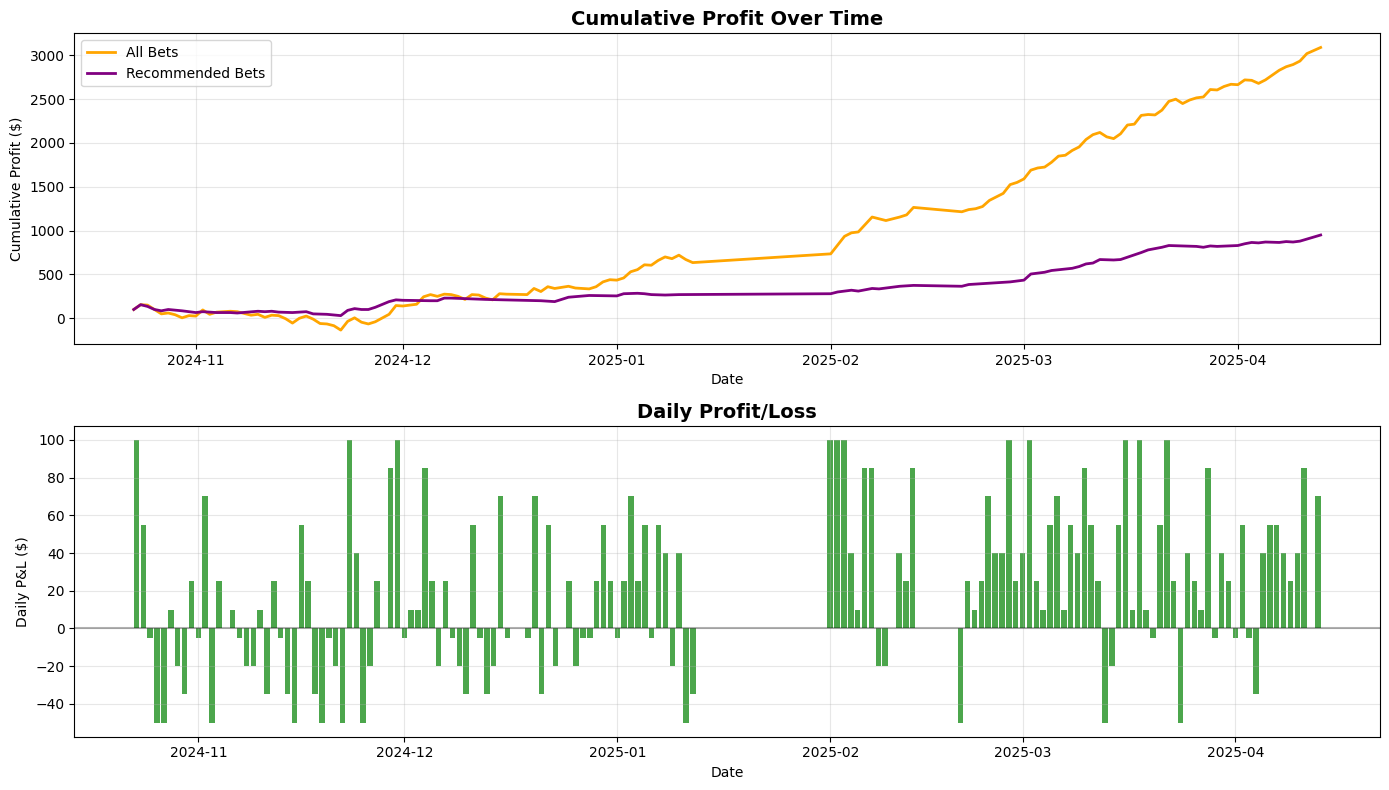

In [29]:
edge = 5.5
# Calculate metrics for all bets
all_metrics = calculatePairMetrics(final_results, stake=5)

# Calculate metrics for recommended bets only
recommended = final_results[final_results['pair_recommendation'] == 1]
rec_metrics = calculatePairMetrics(recommended, stake=5)

# Display comprehensive results
print("=" * 60)
print("           COMPREHENSIVE BETTING ANALYSIS")
print("=" * 60)

if all_metrics:
    print(f"\n ALL BETS ANALYSIS:")
    print(f"   Total Bets: {all_metrics['total_bets']:,}")
    print(f"   Wins: {all_metrics['total_wins']:,}")
    print(f"   Hit Rate: {all_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${all_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${all_metrics['total_staked']:,.2f}")
    print(f"   ROI: {all_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${all_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${all_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {all_metrics['sharpe_ratio']:.3f}")

if rec_metrics:
    print(f"\n RECOMMENDED BETS ANALYSIS (Edge > {edge}):")
    print(f"   Total Bets: {rec_metrics['total_bets']:,}")
    print(f"   Wins: {rec_metrics['total_wins']:,}")
    print(f"   Hit Rate: {rec_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${rec_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${rec_metrics['total_staked']:,.2f}")
    print(f"   ROI: {rec_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${rec_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${rec_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {rec_metrics['sharpe_ratio']:.3f}")

# Plots cumulative profit over time
if all_metrics and not all_metrics['daily_pnl'].empty:
    plt.figure(figsize=(14, 8))
    
    plt.subplot(2, 1, 1)
    plt.plot(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['cumulative_profit'], 
             linewidth=2, label='All Bets', color='orange')
    if rec_metrics and not rec_metrics['daily_pnl'].empty:
        plt.plot(rec_metrics['daily_pnl']['date'], rec_metrics['daily_pnl']['cumulative_profit'], 
                 linewidth=2, label='Recommended Bets', color='purple')
    plt.title('Cumulative Profit Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Profit ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 1, 2)
    plt.bar(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['profit'], 
            alpha=0.7, label='Daily P&L', color='green')
    plt.title('Daily Profit/Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Daily P&L ($)')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [30]:
final_results.to_csv('pairs55edgePrizepicks.csv')